In [ ]:
!pip install -q genomic-benchmarks transformers torch scikit-learn matplotlib

In [ ]:
!pip uninstall deepchem-genomics -y
!pip install --no-cache-dir git+https://github.com/hanara2112/deepchem-genomics.git

Found existing installation: deepchem-genomics 0.1.0
Uninstalling deepchem-genomics-0.1.0:
  Successfully uninstalled deepchem-genomics-0.1.0
  Cloning https://github.com/hanara2112/deepchem-genomics.git to /tmp/pip-req-build-zo21kj1x
  Running command git clone --filter=blob:none --quiet https://github.com/hanara2112/deepchem-genomics.git /tmp/pip-req-build-zo21kj1x
  Resolved https://github.com/hanara2112/deepchem-genomics.git to commit 2c1ce0eab839bcc7c07ac3f581ac1e5933b21b6e
  Preparing metadata (setup.py) ... done
  Created wheel for deepchem-genomics: filename=deepchem_genomics-0.1.0-py3-none-any.whl size=39929 sha256=38e158c501a5a4afab14430b8156f6ba217e574fbb19ed8ea70fc6601bd08007
  Stored in directory: /tmp/pip-ephem-wheel-cache-w1equrpu/wheels/36/d0/09/22896f53243e4f07308429f4091d1772a4726c1e2be28be72b
Successfully built deepchem-genomics


In [ ]:
!pip uninstall -y accelerate

In [ ]:
!pip install accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 26.4 MB/s eta 0:00:00


## Imports

In [ ]:
import time
import warnings
import logging

import numpy as np
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)

from deepchem_genomics.molnet import load_genomic_benchmark
from deepchem_genomics.feat import DNAOneHotFeaturizer, DNAKmerFeaturizer
from deepchem_genomics.models import SimpleCNNModel, LSTMModel

## Load Dataset

In [ ]:
DATASET = "dummy_mouse_enhancers_ensembl"

tasks, (train, valid, test), _ = load_genomic_benchmark(
    dataset_name=DATASET, splitter="random", seed=42)

print(f"\nDataset:  {DATASET}")
print(f"Tasks:    {tasks}")
print(f"Train:    {len(train)} sequences")
print(f"Valid:    {len(valid)} sequences")
print(f"Test:     {len(test)} sequences")
print(f"Classes:  {train.label_map}")


Dataset:  dummy_mouse_enhancers_ensembl
Tasks:    ['dummy_mouse_enhancers_ensembl']
Train:    968 sequences
Valid:    121 sequences
Test:     121 sequences
Classes:  {'negative': 0, 'positive': 1}



Sequence lengths:
  Min=331  Max=4776  Mean=2370  Median=2381

Train class balance:  neg=484  pos=484  ratio=1.00


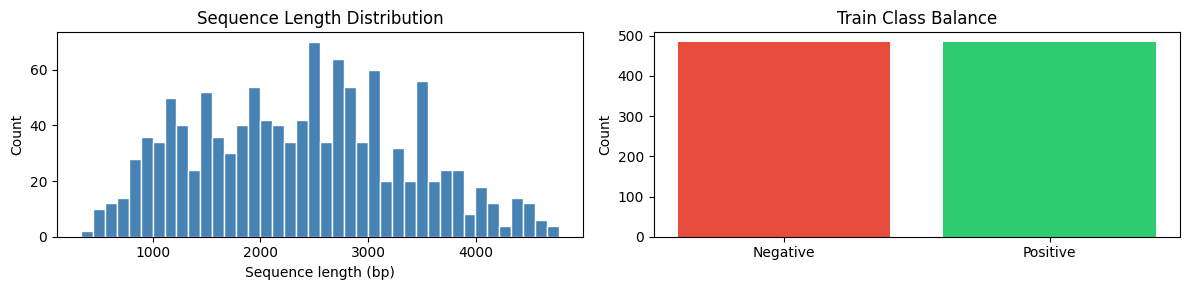

In [ ]:
all_seqs = np.concatenate([train.X, valid.X, test.X])
lengths = np.array([len(s) for s in all_seqs])

print(f"\nSequence lengths:")
print(f"  Min={lengths.min()}  Max={lengths.max()}  "
      f"Mean={lengths.mean():.0f}  Median={np.median(lengths):.0f}")

train_labels = train.y.squeeze()
n_pos = int(train_labels.sum())
n_neg = len(train_labels) - n_pos
print(f"\nTrain class balance:  neg={n_neg}  pos={n_pos}  "
      f"ratio={n_pos / max(n_neg, 1):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(lengths, bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Sequence length (bp)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sequence Length Distribution")
axes[1].bar(["Negative", "Positive"], [n_neg, n_pos],
            color=["#e74c3c", "#2ecc71"])
axes[1].set_title("Train Class Balance")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
MAX_LENGTH = 256

print(f"\nOne-hot encoding with max_length={MAX_LENGTH} ...")
oh = DNAOneHotFeaturizer(max_length=MAX_LENGTH)
t0 = time.time()
X_train_oh = oh.featurize(train.X)
X_valid_oh = oh.featurize(valid.X)
X_test_oh = oh.featurize(test.X)
print(f"  Done in {time.time() - t0:.1f}s")
print(f"  Shape: {X_train_oh.shape} -> (samples, length, channels)")

y_train = train.y.squeeze()
y_valid = valid.y.squeeze()
y_test = test.y.squeeze()


One-hot encoding with max_length=256 ...
  Done in 0.2s
  Shape: (968, 256, 4) -> (samples, length, channels)


In [ ]:
print("\n" + "=" * 55)
print("Training: SimpleCNNModel")
print("=" * 55)

cnn = SimpleCNNModel(
    max_length=MAX_LENGTH, n_filters=64,
    kernel_size=8, batch_size=32,
    learning_rate=1e-3, seed=42, device="cpu")

t0 = time.time()
cnn_loss = cnn.fit(X_train_oh, y_train, nb_epoch=10)
cnn_time = time.time() - t0

cnn_metrics = cnn.evaluate(X_test_oh, y_test)
print(f"\nCNN Results (test set):")
print(f"  ROC-AUC:  {cnn_metrics['roc_auc']:.4f}")
print(f"  Accuracy: {cnn_metrics['accuracy']:.4f}")
print(f"  F1:       {cnn_metrics['f1']:.4f}")
print(f"  Time:     {cnn_time:.1f}s")


Training: SimpleCNNModel

CNN Results (test set):
  ROC-AUC:  0.7685
  Accuracy: 0.6694
  F1:       0.7333
  Time:     2.2s


In [ ]:
print("\n" + "=" * 55)
print("Training: LSTMModel")
print("=" * 55)

lstm = LSTMModel(
    max_length=MAX_LENGTH, hidden_size=64,
    n_layers=1, batch_size=32,
    learning_rate=1e-3, seed=42, device="cpu")

t0 = time.time()
lstm_loss = lstm.fit(X_train_oh, y_train, nb_epoch=10)
lstm_time = time.time() - t0

lstm_metrics = lstm.evaluate(X_test_oh, y_test)
print(f"\nLSTM Results (test set):")
print(f"  ROC-AUC:  {lstm_metrics['roc_auc']:.4f}")
print(f"  Accuracy: {lstm_metrics['accuracy']:.4f}")
print(f"  F1:       {lstm_metrics['f1']:.4f}")
print(f"  Time:     {lstm_time:.1f}s")


Training: LSTMModel

LSTM Results (test set):
  ROC-AUC:  0.7627
  Accuracy: 0.6777
  F1:       0.7111
  Time:     26.3s


In [ ]:
# DNABERT-2 downloads ~500MB of weights on first run.
# Set SKIP_DNABERT2 = True to skip if you only want baselines.

SKIP_DNABERT2 = False

if not SKIP_DNABERT2:
    print("\n" + "=" * 55)
    print("Training: DNABERT2Model")
    print("=" * 55)
    print("(First run downloads ~500MB model weights)")

    from deepchem_genomics.models import DNABERT2Model
    import torch

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    dnabert2 = DNABERT2Model(
        task="classification", n_tasks=1,
        max_seq_length=128, batch_size=8,
        learning_rate=2e-5, device=device)

    t0 = time.time()
    db2_loss = dnabert2.fit(train.X, y_train, nb_epoch=3)
    db2_time = time.time() - t0

    db2_metrics = dnabert2.evaluate(test.X, y_test)
    print(f"\nDNABERT-2 Results (test set):")
    print(f"  ROC-AUC:  {db2_metrics['roc_auc']:.4f}")
    print(f"  Accuracy: {db2_metrics['accuracy']:.4f}")
    print(f"  F1:       {db2_metrics['f1']:.4f}")
    print(f"  Time:     {db2_time:.1f}s")
else:
    db2_metrics = None
    db2_time = None
    print("\n[Skipped DNABERT-2 — set SKIP_DNABERT2 = False to run]")


Training: DNABERT2Model
(First run downloads ~500MB model weights)
Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



DNABERT-2 Results (test set):
  ROC-AUC:  0.8830
  Accuracy: 0.7686
  F1:       0.7627
  Time:     92.5s




  Model Comparison on dummy_mouse_enhancers_ensembl
  Model                    ROC-AUC   Accuracy       F1     Time
-----------------------------------------------------------------
  CNN + One-Hot             0.7685     0.6694   0.7333     2.2s
  BiLSTM + One-Hot          0.7627     0.6777   0.7111    26.3s
  DNABERT-2 + BPE           0.8830     0.7686   0.7627    92.5s


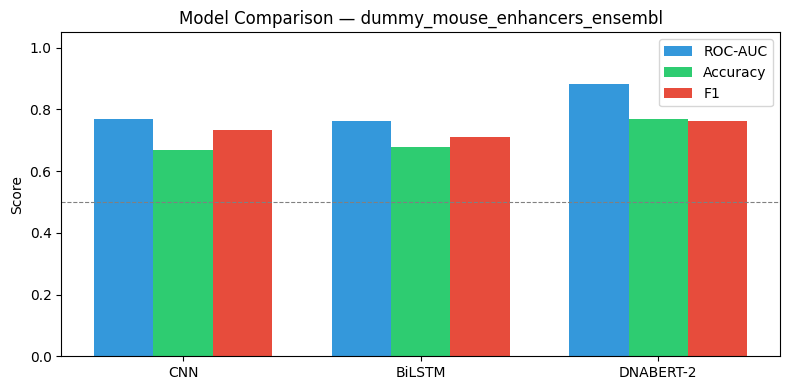

In [ ]:
print("\n")
print("=" * 65)
print(f"  Model Comparison on {DATASET}")
print("=" * 65)
print(f"  {'Model':<22} {'ROC-AUC':>9} {'Accuracy':>10} {'F1':>8} {'Time':>8}")
print("-" * 65)
print(f"  {'CNN + One-Hot':<22} "
      f"{cnn_metrics['roc_auc']:>9.4f} "
      f"{cnn_metrics['accuracy']:>10.4f} "
      f"{cnn_metrics['f1']:>8.4f} "
      f"{cnn_time:>7.1f}s")
print(f"  {'BiLSTM + One-Hot':<22} "
      f"{lstm_metrics['roc_auc']:>9.4f} "
      f"{lstm_metrics['accuracy']:>10.4f} "
      f"{lstm_metrics['f1']:>8.4f} "
      f"{lstm_time:>7.1f}s")
if db2_metrics is not None:
    print(f"  {'DNABERT-2 + BPE':<22} "
          f"{db2_metrics['roc_auc']:>9.4f} "
          f"{db2_metrics['accuracy']:>10.4f} "
          f"{db2_metrics['f1']:>8.4f} "
          f"{db2_time:>7.1f}s")
print("=" * 65)

# Bar chart comparison
models = ["CNN", "BiLSTM"]
aucs = [cnn_metrics["roc_auc"], lstm_metrics["roc_auc"]]
accs = [cnn_metrics["accuracy"], lstm_metrics["accuracy"]]
f1s = [cnn_metrics["f1"], lstm_metrics["f1"]]

if db2_metrics is not None:
    models.append("DNABERT-2")
    aucs.append(db2_metrics["roc_auc"])
    accs.append(db2_metrics["accuracy"])
    f1s.append(db2_metrics["f1"])

x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w, aucs, w, label="ROC-AUC", color="#3498db")
ax.bar(x, accs, w, label="Accuracy", color="#2ecc71")
ax.bar(x + w, f1s, w, label="F1", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Model Comparison — {DATASET}")
ax.legend()
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Random")
plt.tight_layout()
plt.show()